In [2]:
from pathlib import Path
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / ".projectroot").exists())

# GDELT Events : EDA + Preparation

GDELT records geopolitical events from world news, one row per event, coded by who did what to whom (CAMEO). It is used to measure each country's conflict intensity and relationships, which become news-based features for the risk model.

**Input:** BigQuery `iris.gdelt_events` (a fresh GDELT 2.0 pull from the public `gdelt-bq.gdeltv2.events`, around 895M rows from 2015 onward).  
**Output:** `data/interim/gdelt/gdelt_clean.csv` (per-country-month features, keyed on ISO3 and month).

## 1. Setup

I import the libraries, set the output path, and define a small helper that runs a BigQuery SQL through the bq CLI and returns the result as a DataFrame.

In [3]:
import os, io, subprocess
import numpy as np, pandas as pd

OUT_DIR = str(ROOT / "data/interim/gdelt")
TABLE = 'iris.gdelt_events'
pd.set_option('display.max_columns', 40); pd.set_option('display.width', 180)

def run_bq(sql):
    out = subprocess.run(['bq', 'query', '--use_legacy_sql=false', '--format=csv', '--max_rows=5000000', sql],
                         capture_output=True, text=True)
    if out.returncode != 0:
        raise RuntimeError(out.stderr[-800:])
    return pd.read_csv(io.StringIO(out.stdout))

I set one consistent, high-resolution style for every chart (resolution, fonts, sizes, colors).

In [4]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.dpi': 130, 'savefig.dpi': 200,
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'font.family': 'DejaVu Sans', 'font.size': 11,
    'axes.titlesize': 14, 'axes.titleweight': 'bold', 'axes.labelsize': 12,
    'axes.edgecolor': '#444444', 'axes.linewidth': 0.8,
    'axes.grid': True, 'grid.color': '#E9E9E9', 'grid.linewidth': 0.8,
    'xtick.labelsize': 10, 'ytick.labelsize': 10,
    'axes.spines.top': False, 'axes.spines.right': False, 'legend.frameon': False,
})
NAVY, BLUE, RED = '#1F3864', '#2E75B6', '#C0392B'

I check the raw table size and date range, and pull a small sample of rows to see the structure.

In [5]:
meta = run_bq(f'SELECT COUNT(*) AS n_rows, MIN(event_date) AS min_date, MAX(event_date) AS max_date FROM {TABLE}')
print('gdelt_events ->', f"{int(meta.n_rows[0]):,} rows | {meta.min_date[0]} to {meta.max_date[0]}")
with pd.option_context('display.max_columns', None, 'display.width', None):
    display(run_bq(f'SELECT * FROM {TABLE} ORDER BY event_date DESC LIMIT 6'))

gdelt_events -> 894,880,380 rows | 2015-01-01 to 2026-06-09


,GLOBALEVENTID,SQLDATE,MonthYear,Year,FractionDate,Actor1Code,Actor1Name,Actor1CountryCode,Actor1KnownGroupCode,Actor1EthnicCode,Actor1Religion1Code,Actor1Religion2Code,Actor1Type1Code,Actor1Type2Code,Actor1Type3Code,Actor2Code,Actor2Name,Actor2CountryCode,Actor2KnownGroupCode,Actor2EthnicCode,Actor2Religion1Code,Actor2Religion2Code,Actor2Type1Code,Actor2Type2Code,Actor2Type3Code,IsRootEvent,EventCode,EventBaseCode,EventRootCode,QuadClass,GoldsteinScale,NumMentions,NumSources,NumArticles,AvgTone,Actor1Geo_Type,Actor1Geo_FullName,Actor1Geo_CountryCode,Actor1Geo_ADM1Code,Actor1Geo_ADM2Code,Actor1Geo_Lat,Actor1Geo_Long,Actor1Geo_FeatureID,Actor2Geo_Type,Actor2Geo_FullName,Actor2Geo_CountryCode,Actor2Geo_ADM1Code,Actor2Geo_ADM2Code,Actor2Geo_Lat,Actor2Geo_Long,Actor2Geo_FeatureID,ActionGeo_Type,ActionGeo_FullName,ActionGeo_CountryCode,ActionGeo_ADM1Code,ActionGeo_ADM2Code,ActionGeo_Lat,ActionGeo_Long,ActionGeo_FeatureID,DATEADDED,SOURCEURL,event_date
0,1308112257,20260609,202606,2026,2026.4356,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ZWE,ZIMBABWEAN,ZWE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,46,46,4,1,7.0,4,1,4,0.228833,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Zimbabwe,ZI,ZI,NaN,-19.0000,29.0000,ZI,1,Zimbabwe,ZI,ZI,NaN,-19.0000,29.0000,ZI,20260609011500,https://www.newzimbabwe.com/legal-discussions-...,2026-06-09
1,1308117030,20260609,202606,2026,2026.4356,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CVL,VOTER,NaN,NaN,NaN,NaN,NaN,CVL,NaN,NaN,0,43,43,4,1,2.8,2,1,2,-0.760693,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,"Mashonaland West, Mashonaland West, Zimbabwe",ZI,ZI05,40201.0,-17.0000,29.5000,-2315777,5,"Mashonaland West, Mashonaland West, Zimbabwe",ZI,ZI05,40201.0,-17.0000,29.5000,-2315777,20260609020000,https://iharare.com/constitution-amendment-bil...,2026-06-09
2,1308108911,20260609,202606,2026,2026.4356,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ZWE,ZIMBABWE,ZWE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,40,40,4,1,1.0,10,1,10,-2.564103,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Zimbabwe,ZI,ZI,NaN,-19.0000,29.0000,ZI,1,Zimbabwe,ZI,ZI,NaN,-19.0000,29.0000,ZI,20260609004500,https://bulawayo24.com/index-id-news-sc-nation...,2026-06-09
3,1308112146,20260609,202606,2026,2026.4356,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,EDU,STUDENT,NaN,NaN,NaN,NaN,NaN,EDU,NaN,NaN,0,112,112,11,3,-2.0,10,1,10,-3.501401,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,"Harare, Mashonaland East, Zimbabwe",ZI,ZI04,40197.0,-17.8178,31.0447,-2312291,4,"Harare, Mashonaland East, Zimbabwe",ZI,ZI04,40197.0,-17.8178,31.0447,-2312291,20260609011500,https://www.newzimbabwe.com/civic-society-orga...,2026-06-09
4,1308112113,20260609,202606,2026,2026.4356,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AFR,AFRICA,AFR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,112,112,11,3,-2.0,2,1,2,-7.368421,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,"Pretoria, Gauteng, South Africa",SF,SF06,77346.0,-25.7069,28.2294,-1273769,1,Zimbabwe,ZI,ZI,NaN,-19.0000,29.0000,ZI,20260609011500,https://www.newzimbabwe.com/sa-president-ramap...,2026-06-09
5,1308112256,20260609,202606,2026,2026.4356,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ZWE,ZIMBABWE,ZWE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,36,36,3,1,4.0,4,1,4,0.228833,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Zimbabwe,ZI,ZI,NaN,-19.0000,29.0000,ZI,1,Zimbabwe,ZI,ZI,NaN,-19.0000,29.0000,ZI,20260609011500,https://www.newzimbabwe.com/legal-discussions-...,2026-06-09


The fresh pull holds about 895 million events from January 2015 to June 2026. I pulled it from the public GDELT 2.0 table with a single filter, SQLDATE from 2015-01-01, keeping all 61 columns plus a derived event_date. Each row is one event: a date, a CAMEO event classification (EventRootCode, QuadClass), a Goldstein conflict-to-cooperation score, news intensity (NumMentions, AvgTone), the actor countries, and where it happened (ActionGeo). Note the two country-code systems: ActionGeo_CountryCode is FIPS 2-letter while Actor1CountryCode is CAMEO 3-letter. The January 2015 month won't have many recorded events as per GDELT literature.

## 2. Data Discovery

In [6]:
neg2026 = run_bq(f"""
SELECT event_date, ActionGeo_FullName, Actor1Name, Actor1Type1Code, Actor2Name,
       EventRootCode, QuadClass, GoldsteinScale AS goldstein, ROUND(AvgTone, 1) AS tone, NumArticles
FROM {TABLE}
WHERE event_date >= '2026-01-01' AND ActionGeo_CountryCode IS NOT NULL AND NumArticles >= 20
ORDER BY GoldsteinScale ASC, AvgTone ASC, GLOBALEVENTID ASC
LIMIT 1""")
neg2026

,event_date,ActionGeo_FullName,Actor1Name,Actor1Type1Code,Actor2Name,EventRootCode,QuadClass,goldstein,tone,NumArticles
0,2026-04-21,"Parwan, Parvan, Afghanistan",POLICE,COP,KABUL,19,4,-10.0,-23.4,20


`gdelt_events` = one row per geopolitical event detected in world news.

- Each row = one event: who did what to whom, when, where, and how the news covered it.
- How to read a row: an Actor1 acts toward an Actor2, coded by EventRootCode and bucketed by QuadClass (1 verbal cooperation, 2 material cooperation, 3 verbal conflict, 4 material conflict). GoldsteinScale rates it -10 (most conflictual) to +10 (most cooperative), AvgTone is the news sentiment, NumArticles is how many distinct articles covered it, and ActionGeo is where it happened.
- For example, read the row above: on 2026-04-21 in Parwan, Afghanistan, the police (Actor1Name POLICE, Actor1Type1Code COP, law enforcement) were in a fight involving Kabul (Actor2Name KABUL), coded EventRootCode 19 (fight) and QuadClass 4 (material conflict), with GoldsteinScale -10 (the most conflictual score) and a tone of -23.4 (strongly negative), reported by 20 articles. This row is a domestic incident inside one country.

I do a quick coverage check (counts, not a chart here): events per year and the first months of 2015, to confirm the real modeling window and the mid-February 2015 start.

In [7]:
cov_year = run_bq(f'SELECT EXTRACT(YEAR FROM event_date) AS year, COUNT(*) AS n FROM {TABLE} GROUP BY year ORDER BY year')
cov_2015 = run_bq(f"SELECT FORMAT_DATE('%Y-%m', event_date) AS ym, COUNT(*) AS n FROM {TABLE} WHERE event_date < '2015-07-01' GROUP BY ym ORDER BY ym")
print('=== events per year ==='); display(cov_year)
print('=== first months of 2015 ==='); display(cov_2015)

=== events per year ===


,year,n
0,2015,88106092
1,2016,114494536
2,2017,105043785
3,2018,94274806
4,2019,82320409
5,2020,65355708
6,2021,59102171
7,2022,57176321
8,2023,70633141
9,2024,69041825


=== first months of 2015 ===


,ym,n
0,2015-01,104531
1,2015-02,2897974
2,2015-03,8562619
3,2015-04,8022952
4,2015-05,7654542
5,2015-06,7617107


The counts confirm the window. January 2015 has only 104k events, then February jumps to 2.9M and then the following months reach about 8M, so the real-time coverage begins in mid-February 2015. By year, volume peaks around 2016 (about 114M) and declines to roughly 57M by 2022 before recovering. 2026 is also partial as the year has not ended yet.

I check the two country-code systems and their coverage: ActionGeo (where the event happened, FIPS) and Actor1 (who acted, CAMEO), since I must pick one as the country key and map it to ISO3.

In [8]:
geo = run_bq(f'SELECT ActionGeo_CountryCode AS fips, COUNT(*) AS n FROM {TABLE} GROUP BY fips ORDER BY n DESC LIMIT 8')
nulls = run_bq(f'SELECT ROUND(100*COUNTIF(ActionGeo_CountryCode IS NULL)/COUNT(*),1) AS actiongeo_null_pct, ROUND(100*COUNTIF(Actor1CountryCode IS NULL)/COUNT(*),1) AS actor1_null_pct FROM {TABLE}')
print('=== top ActionGeo (FIPS) codes ==='); display(geo)
print('=== null share of each country field (%) ==='); display(nulls)

=== top ActionGeo (FIPS) codes ===


,fips,n
0,US,210351082
1,RS,38012311
2,UK,35968638
3,IN,30117591
4,NaN,27518302
5,IS,26151319
6,UP,24279374
7,CH,22861463


=== null share of each country field (%) ===


,actiongeo_null_pct,actor1_null_pct
0,3.1,46.8


This decides the country key. ActionGeo (where the event happened) is almost fully populated at only 3.1% null, while Actor1 (who acted) is null 46.8% of the time, so ActionGeo is the far better choice and also the right meaning for risk located in a country. The top locations are the news-heavy states (US dominant at 210M, then Russia, UK, India, Israel, Ukraine, China). ActionGeo uses FIPS 2-letter codes (US, RS Russia, UP Ukraine, CH China), so the key cleaning step will be a guarded FIPS-to-ISO3 map.

I look at the core event fields I will turn into features: the QuadClass split, the most common event types (EventRootCode), and the average Goldstein and tone, to understand the signal before aggregating.

In [9]:
qc = run_bq(f'SELECT QuadClass, COUNT(*) AS n FROM {TABLE} GROUP BY QuadClass ORDER BY QuadClass')
qc['pct'] = (100 * qc.n / qc.n.sum()).round(1)
er = run_bq(f'SELECT EventRootCode, COUNT(*) AS n FROM {TABLE} GROUP BY EventRootCode ORDER BY n DESC LIMIT 6')
stats = run_bq(f'SELECT ROUND(AVG(GoldsteinScale),2) AS avg_goldstein, ROUND(AVG(AvgTone),2) AS avg_tone, ROUND(AVG(NumMentions),1) AS avg_mentions FROM {TABLE}')
print('=== QuadClass split (1 verbal-coop, 2 material-coop, 3 verbal-conflict, 4 material-conflict) ==='); display(qc)
print('=== top EventRootCodes ==='); display(er)
print('=== overall averages ==='); display(stats)

=== QuadClass split (1 verbal-coop, 2 material-coop, 3 verbal-conflict, 4 material-conflict) ===


,QuadClass,n,pct
0,1,548594848,61.3
1,2,104374267,11.7
2,3,116847755,13.1
3,4,125063510,14.0


=== top EventRootCodes ===


,EventRootCode,n
0,4,222394182
1,1,117413430
2,5,78250665
3,2,67475370
4,3,63061046
5,19,57452136


=== overall averages ===


,avg_goldstein,avg_tone,avg_mentions
0,0.56,-1.96,5.9


- Events are mostly cooperative and verbal: QuadClass 1 (verbal cooperation) is 61%, material cooperation 12%, verbal conflict 13%, and material conflict 14%. 
- The most common event types are diplomatic (consult, public statement, appeal), but code 19 (fight) ranks sixth with 57M events, it is a large direct-violence signal. 
- Overall Goldstein averages +0.56 (mildly cooperative) and tone -1.96 (news skews slightly negative). The conflict share, Goldstein, tone, and violence counts are exactly the fields I will aggregate per country.

Before building, I check nulls across all 62 columns and check the event ID for duplicates.

In [10]:
cols = run_bq(f"SELECT column_name FROM iris.INFORMATION_SCHEMA.COLUMNS WHERE table_name='gdelt_events' ORDER BY ordinal_position")['column_name'].tolist()
sel = ', '.join([f'ROUND(100*COUNTIF(`{c}` IS NULL)/COUNT(*),1) AS `{c}`' for c in cols])
nullpct = run_bq(f'SELECT {sel} FROM {TABLE}').T.rename(columns={0: 'null_pct'}).sort_values('null_pct', ascending=False)
dups = run_bq(f'SELECT COUNT(*) AS n_rows, COUNT(DISTINCT GLOBALEVENTID) AS n_distinct, COUNT(*)-COUNT(DISTINCT GLOBALEVENTID) AS dup_rows FROM {TABLE}')
print('=== null % per column (all 62), highest first ==='); display(nullpct)
print('=== duplicate event IDs ==='); display(dups)

=== null % per column (all 62), highest first ===


,null_pct
Actor2Type3Code,100.0
Actor1Type3Code,99.9
Actor2Religion2Code,99.7
Actor1Religion2Code,99.6
Actor2EthnicCode,99.5
...,...
IsRootEvent,0.0
FractionDate,0.0
Year,0.0
MonthYear,0.0


=== duplicate event IDs ===


,n_rows,n_distinct,dup_rows
0,894880380,894880380,0


- Heavily-null columns are actor sub-attributes I do not use: Type3, religion, ethnic, and known-group codes (97 to 100% null). The Actor2 fields are often null too (30 to 66%, many events have no second actor). I drop the sub-attributes but keep Actor2CountryCode for the relational features.
- ActionGeo is about 3.1% null, since I will use it as the country key, I will drop the rows where ActionGeo null.
- GLOBALEVENTID is unique with zero duplicate rows. 

## 3. Data Preparation

I started by converting FIPS country coding to the universal ISO3 country coding so the ActionGeo can join the rest of the data sets.

In [11]:
import geopandas as gpd
ne = gpd.read_file(str(ROOT / "data/external/geodata/ne_110m_admin_0_countries.geojson"))[['FIPS_10', 'ISO_A3_EH']].dropna()
ne = ne[ne['ISO_A3_EH'].str.match(r'^[A-Z]{3}$')]
SUP = {'IS':'ISR','NO':'NOR','SN':'SGP','RB':'SRB','WE':'PSE','GZ':'PSE','HK':'HKG','BA':'BHR','MP':'MUS',
       'MT':'MLT','KV':'XKX','JE':'JEY','OD':'SSD','GP':'GLP','BB':'BRB','MV':'MDV','GQ':'GUM','VT':'VAT',
       'BD':'BMU','MN':'MCO','WS':'WSM','RE':'REU','SE':'SYC','GI':'GIB','DO':'DMA','GJ':'GRD','VC':'VCT',
       'AN':'AND','MC':'MAC','TN':'TON','AC':'ATG','PS':'PLW','CJ':'CYM','GK':'GGY','ST':'LCA','MB':'MTQ',
       'VQ':'VIR','NR':'NRU','CV':'CPV','CW':'COK','RM':'MHL','CN':'COM','AA':'ABW','MH':'MSR','FP':'PYF',
       'LS':'LIE','KR':'KIR','FM':'FSM','VI':'VGB','SC':'KNA','AQ':'ASM','TV':'TUV','TP':'STP','TK':'TCA',
       'AV':'AIA','SM':'SMR','FO':'FRO','FG':'GUF','KT':'CXR','SH':'SHN','NE':'NIU','IM':'IMN','IO':'IOT',
       'CQ':'MNP','PC':'PCN','TL':'TKL','NF':'NFK','SB':'SPM','WF':'WLF','MF':'MAF','SV':'SJM','RN':'BLM'}
FIPS2ISO = {**dict(zip(ne['FIPS_10'], ne['ISO_A3_EH'])), **SUP}
print('converted entries:', len(FIPS2ISO))

converted entries: 243


I now have 243 countries. What is left unmapped are genuine non-countries (oceans, uninhabited islands), which are dropped out. Next, I aggregate events by month in BigQuery, computing a count and a sum for each candidate feature (filters: from Feb 2015, NumArticles >= 2, non-null location).

In [12]:
agg_sql = f"""
SELECT ActionGeo_CountryCode AS fips, DATE_TRUNC(event_date, MONTH) AS month,
  COUNT(*) AS event_count,
  SUM(GoldsteinScale) AS sum_gold, SUM(AvgTone) AS sum_tone,
  COUNTIF(QuadClass IN (3,4)) AS conflict_count,
  COUNTIF(QuadClass = 4) AS material_conflict_count,
  COUNTIF(QuadClass IN (1,2)) AS coop_count,
  COUNTIF(EventRootCode = '14') AS protest_count,
  COUNTIF(EventRootCode IN ('18','19','20')) AS violence_count,
  COUNTIF(EventRootCode IN ('15','18','19','20')) AS force_count,
  COUNTIF(EventRootCode = '13') AS threat_count
FROM {TABLE}
WHERE event_date >= '2015-02-01' AND NumArticles >= 2 AND ActionGeo_CountryCode IS NOT NULL
GROUP BY fips, month"""
loc = run_bq(agg_sql)
loc['iso3'] = loc['fips'].map(FIPS2ISO)
loc = loc[loc['iso3'].notna()]
comp = ['event_count','sum_gold','sum_tone','conflict_count','material_conflict_count','coop_count','protest_count','violence_count','force_count','threat_count']
loc = loc.groupby(['iso3','month'], as_index=False)[comp].sum()
print('location rows ->', loc.shape, '| countries:', loc.iso3.nunique())
loc.head(3)

location rows -> (32627, 12) | countries: 239


,iso3,month,event_count,sum_gold,sum_tone,conflict_count,material_conflict_count,coop_count,protest_count,violence_count,force_count,threat_count
0,ABW,2015-02-01,199,338.1,81.128919,36,8,163,1,3,3,4
1,ABW,2015-03-01,859,1566.9,373.985658,139,41,720,4,21,21,5
2,ABW,2015-04-01,392,724.8,117.954587,52,18,340,4,12,12,4


The aggregation returns 32,627 country-months. After mapping to ISO3, dropping non-countries, and merging any FIPS codes that share an ISO3, that comes out to 239 countries. These are still raw counts and sums though, not the final features yet. Next I turn those counts and sums into the final features: averages (sum divided by count) and shares (count divided by event_count). Shares are rates, so they're comparable across big and small countries.

In [13]:
g = loc.copy()
g['gdelt_event_count'] = g['event_count']
g['gdelt_avg_goldstein'] = (g['sum_gold'] / g['event_count']).round(3)
g['gdelt_avg_tone'] = (g['sum_tone'] / g['event_count']).round(3)
for name, cnt in [('conflict','conflict_count'),('material_conflict','material_conflict_count'),
                  ('protest','protest_count'),('violence','violence_count'),
                  ('force','force_count'),('threat','threat_count'),('coop','coop_count')]:
    g[f'gdelt_{name}_count'] = g[cnt]
    g[f'gdelt_{name}_share'] = (g[cnt] / g['event_count']).round(4)
feat_cols = ['gdelt_event_count','gdelt_avg_goldstein','gdelt_avg_tone'] + \
    [f'gdelt_{n}_{s}' for n in ['conflict','material_conflict','protest','violence','force','threat','coop'] for s in ['count','share']]
loc_feats = g[['iso3','month'] + feat_cols].copy()
loc_feats['month'] = pd.to_datetime(loc_feats['month'])
print('features:', len(feat_cols)); loc_feats.head(3)

features: 17


,iso3,month,gdelt_event_count,gdelt_avg_goldstein,gdelt_avg_tone,gdelt_conflict_count,gdelt_conflict_share,gdelt_material_conflict_count,gdelt_material_conflict_share,gdelt_protest_count,gdelt_protest_share,gdelt_violence_count,gdelt_violence_share,gdelt_force_count,gdelt_force_share,gdelt_threat_count,gdelt_threat_share,gdelt_coop_count,gdelt_coop_share
0,ABW,2015-02-01,199,1.699,0.408,36,0.1809,8,0.0402,1,0.0050,3,0.0151,3,0.0151,4,0.0201,163,0.8191
1,ABW,2015-03-01,859,1.824,0.435,139,0.1618,41,0.0477,4,0.0047,21,0.0244,21,0.0244,5,0.0058,720,0.8382
2,ABW,2015-04-01,392,1.849,0.301,52,0.1327,18,0.0459,4,0.0102,12,0.0306,12,0.0306,4,0.0102,340,0.8673


I now have 17 location-based features per country-month: the event volume, average Goldstein and tone, and a count plus a share for each of conflict, material conflict, protest, violence, force, threat, and cooperation. I will next add the relational features, such as bilateral interstate conflict events, per country-month the top_adversary (the counterparty it has the most conflict events with) and adversary_concentration (whether or not conflict is focused on one rival or spread across many).

In [14]:
rel_sql = f"""
WITH bil AS (
  SELECT Actor1CountryCode a1, Actor2CountryCode a2, DATE_TRUNC(event_date, MONTH) month
  FROM {TABLE}
  WHERE event_date >= '2015-02-01' AND NumArticles >= 2 AND QuadClass IN (3,4)
    AND REGEXP_CONTAINS(Actor1CountryCode, r'^[A-Z]{{3}}$') AND REGEXP_CONTAINS(Actor2CountryCode, r'^[A-Z]{{3}}$')
    AND Actor1CountryCode != Actor2CountryCode),
pairs AS (SELECT a1 country, a2 counterparty, month FROM bil
          UNION ALL SELECT a2 country, a1 counterparty, month FROM bil),
cc AS (SELECT country, counterparty, month, COUNT(*) n FROM pairs GROUP BY country, counterparty, month),
tot AS (SELECT country, month, SUM(n) total, SUM(POW(n,2)) sumsq FROM cc GROUP BY country, month)
SELECT t.country AS iso3, t.month,
  ROUND(t.sumsq / POW(t.total,2), 3) AS gdelt_adversary_concentration,
  ARRAY_AGG(cc.counterparty ORDER BY cc.n DESC LIMIT 1)[OFFSET(0)] AS top_adversary,
  t.total AS bilateral_conflict_events
FROM tot t JOIN cc USING (country, month)
GROUP BY t.country, t.month, t.total, t.sumsq"""
rel = run_bq(rel_sql)
rel['month'] = pd.to_datetime(rel['month'])
print('relational rows ->', rel.shape, '| countries:', rel.iso3.nunique())
rel.head(3)

relational rows -> (29368, 5) | countries: 222


,iso3,month,gdelt_adversary_concentration,top_adversary,bilateral_conflict_events
0,ISR,2015-02-01,0.201,PSE,7361
1,MDV,2015-02-01,0.114,USA,880
2,EUR,2015-02-01,0.059,RUS,4642


29,368 country-months have at least one bilateral interstate conflict (222 countries), so they get a top_adversary and an adversary_concentration. The concentration is the HHI over counterparties and top_adversary is the most-fought counterparty (Ukraine's resolves to Russia, as verified earlier). Next, I merge the location features with the relational ones on country-month, finalizing the GDELT country-month table.

In [15]:
gdelt = loc_feats.merge(rel, on=['iso3','month'], how='left').sort_values(['iso3','month']).reset_index(drop=True)
print('gdelt ->', gdelt.shape, '| countries:', gdelt.iso3.nunique(), '| months:', gdelt.month.min().date(), '-', gdelt.month.max().date())
gdelt.head(3)

gdelt -> (32627, 22) | countries: 239 | months: 2015-02-01 - 2026-06-01


,iso3,month,gdelt_event_count,gdelt_avg_goldstein,gdelt_avg_tone,gdelt_conflict_count,gdelt_conflict_share,gdelt_material_conflict_count,gdelt_material_conflict_share,gdelt_protest_count,gdelt_protest_share,gdelt_violence_count,gdelt_violence_share,gdelt_force_count,gdelt_force_share,gdelt_threat_count,gdelt_threat_share,gdelt_coop_count,gdelt_coop_share,gdelt_adversary_concentration,top_adversary,bilateral_conflict_events
0,ABW,2015-02-01,199,1.699,0.408,36,0.1809,8,0.0402,1,0.0050,3,0.0151,3,0.0151,4,0.0201,163,0.8191,0.333,USA,6.0
1,ABW,2015-03-01,859,1.824,0.435,139,0.1618,41,0.0477,4,0.0047,21,0.0244,21,0.0244,5,0.0058,720,0.8382,0.411,USA,25.0
2,ABW,2015-04-01,392,1.849,0.301,52,0.1327,18,0.0459,4,0.0102,12,0.0306,12,0.0306,4,0.0102,340,0.8673,0.500,VEN,4.0


The final table is 32,627 country-months across 239 countries, 2015-02 to 2026-06, with 22 columns: iso3, month, the 17 location features, adversary_concentration, and top_adversary plus bilateral_conflict_events.

## 4. Exploratory Data Analysis

I ran a redundancy audit, many of the 18 trainable features overlap by construction (each count with its share, force with violence, coop with conflict). I compute the Spearman correlation heatmap to decide which to drop.

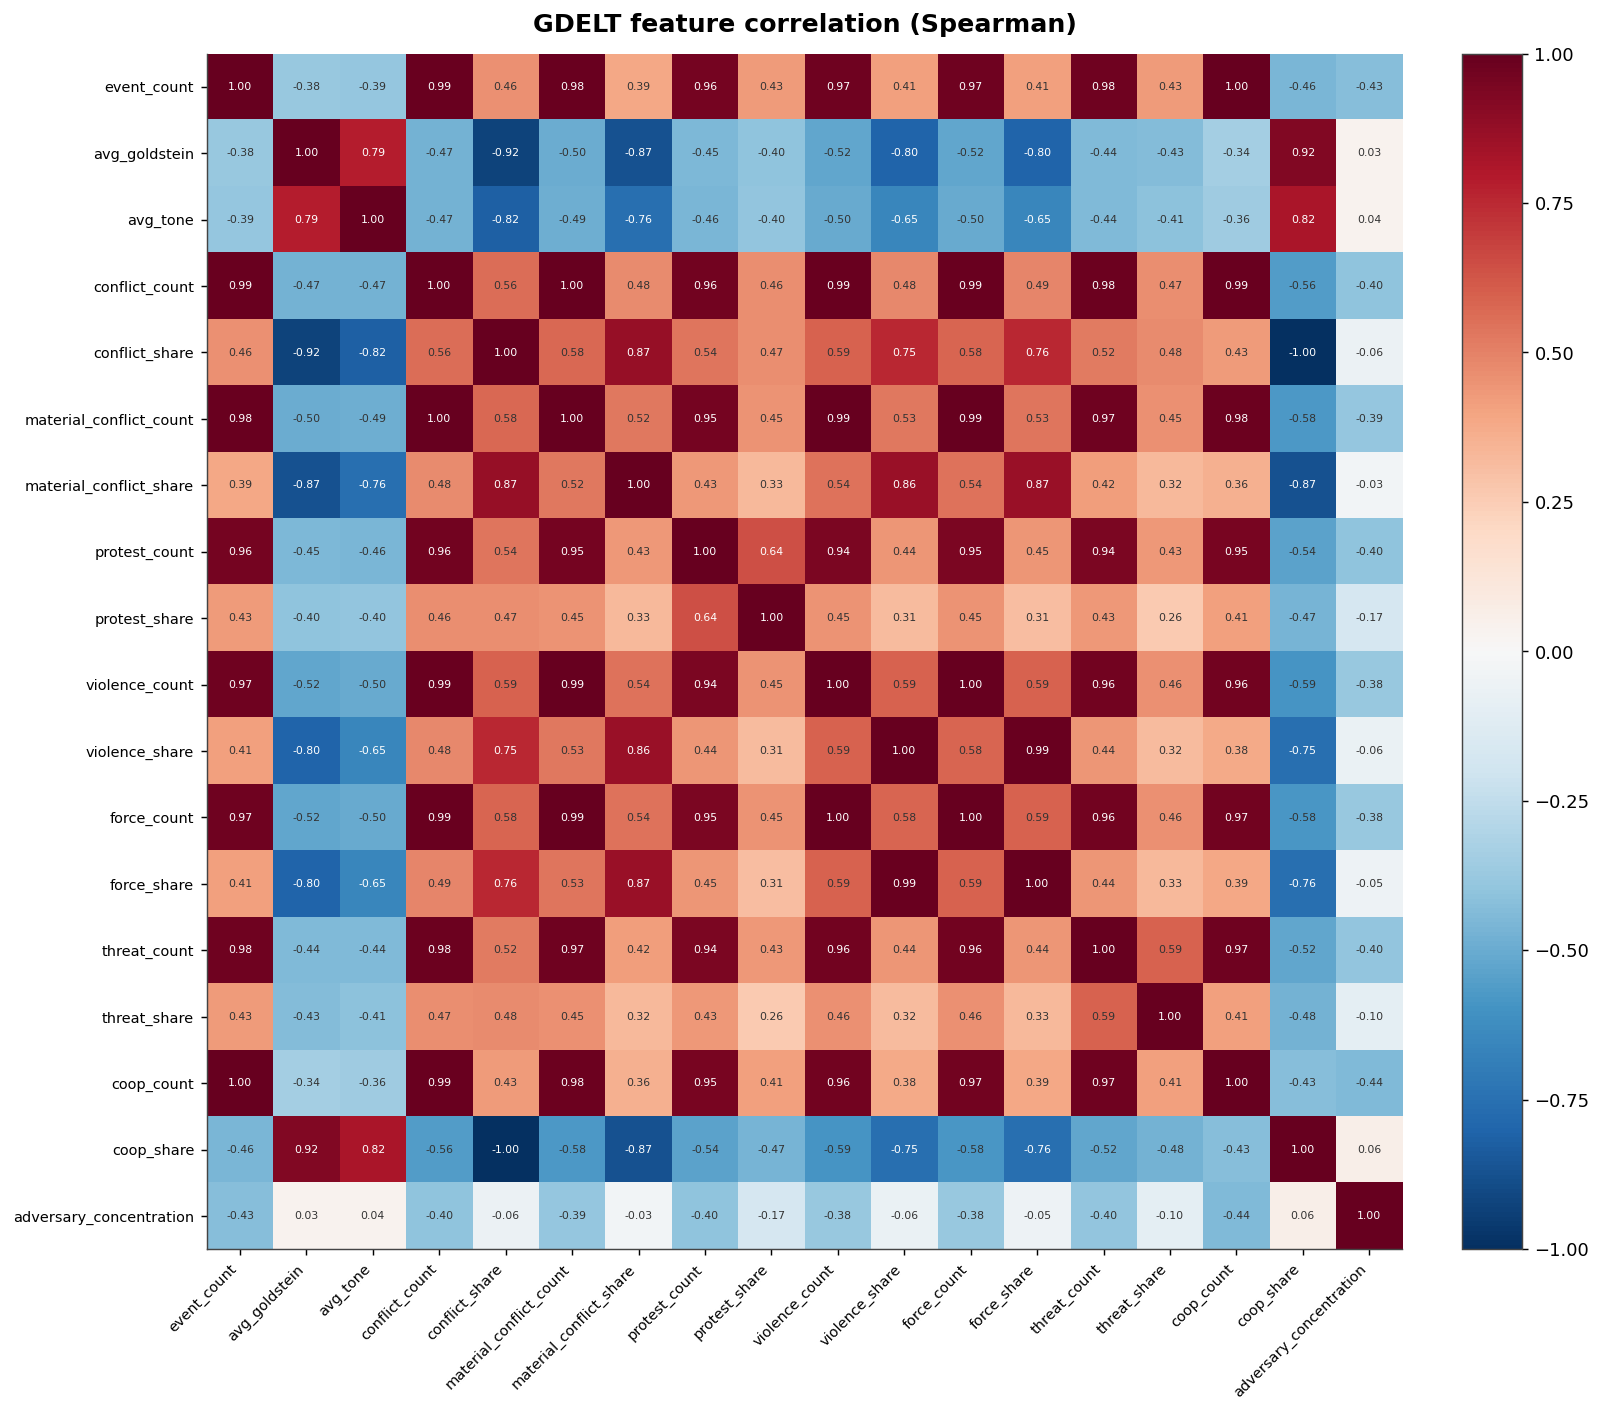

In [16]:
feat18 = ['gdelt_event_count','gdelt_avg_goldstein','gdelt_avg_tone'] + \
    [f'gdelt_{n}_{s}' for n in ['conflict','material_conflict','protest','violence','force','threat','coop'] for s in ['count','share']] + \
    ['gdelt_adversary_concentration']
corr = gdelt[feat18].corr(method='spearman')
fig, ax = plt.subplots(figsize=(13, 11))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.grid(False)
ax.set_xticks(range(len(feat18))); ax.set_xticklabels([f.replace('gdelt_','') for f in feat18], rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(feat18))); ax.set_yticklabels([f.replace('gdelt_','') for f in feat18], fontsize=8)
for i in range(len(feat18)):
    for j in range(len(feat18)):
        ax.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center', color='white' if abs(corr.iloc[i,j])>0.6 else '#333', fontsize=6)
fig.colorbar(im, fraction=0.046, pad=0.04); ax.set_title('GDELT feature correlation (Spearman)', pad=12)
fig.tight_layout(); plt.show()

The audit confirms heavy redundancy. Every category count correlates 0.96 to 1.00 with event_count, so they add nothing beyond it. coop_share mirrors conflict_share (r=-1.00), and conflict_share duplicates avg_goldstein (r=-0.92, more conflict means lower goldstein). force_share also duplicates violence_share (0.99). So I keep event_count for volume, avg_goldstein and avg_tone for intensity/sentiment, and the distinct severity shares (material_conflict, violence, protest, threat), dropping the rest. Next, I aggregate the GDELT features to country-year, and compared correlation to the target : GPR.

In [17]:
gd = gdelt.copy(); gd['year'] = gd['month'].dt.year
gy = gd.groupby(['iso3','year'])[feat18].mean().reset_index()
gpr = pd.read_csv(str(ROOT / "data/interim/gpr/gpr_monthly.csv"))
gpr['year'] = pd.to_datetime(gpr['month']).dt.year
tgt = gpr[(gpr.year>=2015)&(gpr.year<=2023)].groupby(['iso3','year'])['gpr'].mean().reset_index()
ms = gy.merge(tgt, on=['iso3','year'], how='inner')
print('labeled country-years:', len(ms), '| countries:', ms.iso3.nunique())
ms[feat18+['gpr']].corr('spearman')['gpr'].drop('gpr').sort_values(ascending=False).to_frame('spearman_with_gpr').round(3)

labeled country-years: 396 | countries: 44


,spearman_with_gpr
gdelt_threat_count,0.707
gdelt_event_count,0.683
gdelt_coop_count,0.681
gdelt_material_conflict_count,0.677
gdelt_conflict_count,0.677
gdelt_force_count,0.675
gdelt_violence_count,0.664
gdelt_protest_count,0.613
gdelt_threat_share,0.387
gdelt_force_share,0.357


Across 396 labeled country-years (44 countries) the counts correlate most with GPR (0.61 to 0.71), because GPR is news-volume driven and counts track volume, the shares are weaker (0.30 to 0.39). avg_goldstein and avg_tone are negatively correlated. adversary_concentration is weak. Next, I look at each major country's historical top adversary, the counterparty it most often had its monthly top conflict with. This is descriptive only, not a model input. It's the "most likely threat" insight, meant as a future product feature for this project.

In [18]:
gprc = ['USA','RUS','CHN','UKR','ISR','IND','GBR','FRA','DEU','JPN','KOR','TUR','SAU','EGY','BRA','ZAF']
ta = (gdelt.dropna(subset=['top_adversary'])
          .groupby(['iso3','top_adversary']).size().reset_index(name='months'))
hist = ta.sort_values('months', ascending=False).groupby('iso3').first()
hist[hist.index.isin(gprc)].reindex(gprc).dropna()[['top_adversary','months']]

,top_adversary,months
iso3,,
USA,RUS,52
RUS,UKR,96
CHN,USA,128
UKR,RUS,135
ISR,PSE,129
IND,PAK,78
GBR,USA,115
FRA,USA,92
DEU,RUS,53


I observe that each country's historical top adversary is accurate, Ukraine -> Russia, India -> Pakistan, South Korea -> North Korea, Saudi Arabia -> Yemen, Israel -> Palestine, Turkey -> Syria, Egypt -> Israel. (Several countries refer to the USA, which reflects the US being the most-mentioned country in world news). Next, A per-country conflict timeline. The dropdowns pick up to two countries and plot their GDELT violence share over time, to confirm the feature rises during real conflicts.

In [19]:
from ipywidgets import interact, Dropdown, Layout
WSTYLE = {'description_width': '110px'}; WIDE = Layout(width='430px')
isos = sorted(gdelt.iso3.unique())

def violence_timeline(country_1='UKR', country_2='RUS'):
    sel = [c for c in [country_1, country_2] if c != '(none)']
    fig, ax = plt.subplots(figsize=(12, 6))
    for c, col in zip(sel, [RED, NAVY]):
        s = gdelt[gdelt.iso3 == c].sort_values('month')
        ax.plot(s.month, s.gdelt_violence_share, lw=1.8, color=col, label=c)
    ax.set_xlabel('Month'); ax.set_ylabel('Violence share')
    ax.set_title('GDELT violence share over time', pad=12)
    ax.legend(); fig.tight_layout(); plt.show()

interact(violence_timeline,
  country_1=Dropdown(options=isos, value='UKR', description='Country 1', style=WSTYLE, layout=WIDE),
  country_2=Dropdown(options=['(none)'] + isos, value='RUS', description='Country 2', style=WSTYLE, layout=WIDE))

interactive(children=(Dropdown(description='Country 1', index=221, layout=Layout(width='430px'), options=('ABW…

<function __main__.violence_timeline(country_1='UKR', country_2='RUS')>

With Ukraine and Russia chosen, the two lines track each other. Both sit low and close together before 2022, then climb sharply around the February 2022 invasion and stay high through the war, and spike around the same time showing a positive correlation. This makes sense, since the two countries are opposite sides of the same conflict, so their news violence shares rise and fall together. Next, I visualized a world choropleth of violence_share.

In [20]:
import geopandas as gpd
from ipywidgets import interact, Dropdown, Layout
WSTYLE = {'description_width': '110px'}; WIDE = Layout(width='430px')

world = gpd.read_file(str(ROOT / "data/external/geodata/ne_110m_admin_0_countries.geojson"))[['ISO_A3_EH', 'geometry']]
gy = gdelt.assign(year=pd.to_datetime(gdelt['month']).dt.year)
year_opts = ['Mean (all years)'] + [str(y) for y in sorted(gy.year.unique())]

def choropleth(year='Mean (all years)'):
    if year == 'Mean (all years)':
        mv = gdelt.groupby('iso3')['gdelt_violence_share'].mean().reset_index()
        title = 'Mean GDELT violence share by country, 2015 to 2026'
    else:
        mv = gy[gy.year == int(year)].groupby('iso3')['gdelt_violence_share'].mean().reset_index()
        title = f'Mean GDELT violence share by country, {year}'
    m = world.merge(mv, left_on='ISO_A3_EH', right_on='iso3', how='left')
    fig, ax = plt.subplots(figsize=(13, 6.5))
    m.plot(column='gdelt_violence_share', ax=ax, cmap='OrRd', legend=True,
           vmin=0, vmax=0.35, edgecolor='#999999', linewidth=0.3,
           missing_kwds={'color': '#EEEEEE', 'label': 'no data'})
    ax.set_title(title, pad=12); ax.axis('off')
    fig.tight_layout(); plt.show()

interact(choropleth, year=Dropdown(options=year_opts, value='Mean (all years)', description='Year', style=WSTYLE, layout=WIDE))

interactive(children=(Dropdown(description='Year', layout=Layout(width='430px'), options=('Mean (all years)', …

<function __main__.choropleth(year='Mean (all years)')>

The map puts conflict exactly where expected. The Middle East (Syria, Yemen, Iraq, Israel/Palestine) lights up from active wars and unrest, Somalia and Sudan from civil conflict, Afghanistan from decades of fighting, and Ukraine from the Russian invasion. North America, Western Europe, and East Asia stay relatively low low, reflecting their relative stability over the period.

Based on the redundancy audit, I drop the redundant features (all category counts except event_count, plus coop_share, force_share, conflict_share)

In [21]:
KEEP = ['iso3','month',
        'gdelt_event_count','gdelt_avg_goldstein','gdelt_avg_tone',
        'gdelt_material_conflict_share','gdelt_violence_share','gdelt_protest_share',
        'gdelt_threat_share','gdelt_adversary_concentration',
        'top_adversary','bilateral_conflict_events']
gdelt = gdelt[KEEP]
print('pruned gdelt ->', gdelt.shape)
gdelt.head(3)

pruned gdelt -> (32627, 12)


,iso3,month,gdelt_event_count,gdelt_avg_goldstein,gdelt_avg_tone,gdelt_material_conflict_share,gdelt_violence_share,gdelt_protest_share,gdelt_threat_share,gdelt_adversary_concentration,top_adversary,bilateral_conflict_events
0,ABW,2015-02-01,199,1.699,0.408,0.0402,0.0151,0.0050,0.0201,0.333,USA,6.0
1,ABW,2015-03-01,859,1.824,0.435,0.0477,0.0244,0.0047,0.0058,0.411,USA,25.0
2,ABW,2015-04-01,392,1.849,0.301,0.0459,0.0306,0.0102,0.0102,0.500,VEN,4.0


The table is now 12 columns: iso3, month, the 8 trainable features (event_count, avg_goldstein, avg_tone, material_conflict_share, violence_share, protest_share, threat_share, adversary_concentration), and the 2 descriptive relational columns (top_adversary, bilateral_conflict_events). The 10 redundant features are dropped.

Next, I wanted to see the top-adversaries per country to see who it clashes with most, ranked by conflict events or actual violence events.

In [22]:
valid_iso3 = "', '".join(sorted(gdelt.iso3.unique()))

adv_sql = f"""
WITH bil AS (
  SELECT Actor1CountryCode a1, Actor2CountryCode a2, EventRootCode,
         EXTRACT(YEAR FROM event_date) AS year
  FROM {TABLE}
  WHERE event_date>='2015-02-01' AND NumArticles>=2 AND QuadClass IN (3,4)
    AND Actor1CountryCode IN ('{valid_iso3}') AND Actor2CountryCode IN ('{valid_iso3}')
    AND Actor1CountryCode != Actor2CountryCode),
pairs AS (SELECT a1 country, a2 counterparty, EventRootCode, year FROM bil
          UNION ALL SELECT a2 country, a1 counterparty, EventRootCode, year FROM bil)
SELECT country, counterparty, year, COUNT(*) AS conflict_events,
  COUNTIF(EventRootCode IN ('18','19','20')) AS violence_events
FROM pairs GROUP BY country, counterparty, year"""
adversaries = run_bq(adv_sql)
print('adversary pairs ->', adversaries.shape)
adversaries.head(3)

adversary pairs -> (224788, 5)


,country,counterparty,year,conflict_events,violence_events
0,SWE,NOR,2015,623,185
1,SAU,BEL,2015,117,43
2,PAK,CZE,2015,77,63


In [23]:
adv_years = ['Total'] + [str(y) for y in sorted(adversaries.year.unique())]

def top_adversaries(country='UKR', year='Total', top_n=5, rank_by='conflict_events'):
    d = adversaries[adversaries.country == country]
    if year != 'Total':
        d = d[d.year == int(year)]
    d = d.groupby('counterparty', as_index=False)[['conflict_events', 'violence_events']].sum()
    if d.empty or d[rank_by].sum() == 0:
        print('no bilateral conflict data for', country, 'in', year); return
    total = d[rank_by].sum()
    t = d.nlargest(top_n, rank_by)[::-1]
    fig, ax = plt.subplots(figsize=(10, 6.5))
    ax.barh(t.counterparty, t[rank_by], color=RED, edgecolor='white', linewidth=0.5, zorder=3)
    for i, v in enumerate(t[rank_by]):
        ax.text(v, i, f'  {100*v/total:.0f}%', va='center', fontsize=9, color='#333')
    label = rank_by.replace('_', ' ')
    ax.set_xlabel(label.capitalize())
    ax.set_title(f'Top adversaries of {country} ({year}), by {label}', pad=12)
    ax.grid(axis='y', visible=False); fig.tight_layout(); plt.show()

interact(top_adversaries,
  country=Dropdown(options=sorted(adversaries.country.unique()), value='UKR', description='Country', style=WSTYLE, layout=WIDE),
  year=Dropdown(options=adv_years, value='Total', description='Year', style=WSTYLE, layout=WIDE),
  top_n=Dropdown(options=[5, 8, 10, 15], value=5, description='Top N', style=WSTYLE, layout=WIDE),
  rank_by=Dropdown(options=['conflict_events', 'violence_events'], value='conflict_events', description='Rank by', style=WSTYLE, layout=WIDE))

interactive(children=(Dropdown(description='Country', index=185, layout=Layout(width='430px'), options=('ABW',…

<function __main__.top_adversaries(country='UKR', year='Total', top_n=5, rank_by='conflict_events')>

With Ukraine chosen by default, the top adversary is clear. Russia accounts for 66% of Ukraine's conflict events, with the USA as a very distant second at 7%, then Poland, Germany, and Belarus in low single digits. Next, I plot the top conflict flows as a Sankey, Aggressor on the left, target on the right.

In [24]:
flow_sql = f"""
SELECT EXTRACT(YEAR FROM event_date) AS year, Actor1CountryCode AS aggressor, Actor2CountryCode AS target,
  COUNT(*) AS conflict_events, COUNTIF(EventRootCode IN ('18','19','20')) AS violence_events
FROM {TABLE}
WHERE event_date >= '2015-02-01' AND NumArticles >= 2 AND QuadClass IN (3,4)
  AND REGEXP_CONTAINS(Actor1CountryCode, r'^[A-Z]{{3}}$') AND REGEXP_CONTAINS(Actor2CountryCode, r'^[A-Z]{{3}}$')
  AND Actor1CountryCode != Actor2CountryCode
GROUP BY year, aggressor, target"""
flows = run_bq(flow_sql)
print('directed flow rows ->', flows.shape)
flows.head(3)

directed flow rows -> (211340, 5)


,year,aggressor,target,conflict_events,violence_events
0,2015,BWA,ZMB,42,17
1,2015,AUS,FRA,1740,450
2,2015,ZMB,MWI,62,22


In [25]:
import plotly.graph_objects as go
from ipywidgets import interact, Dropdown, IntSlider, Layout
YEARS = ['Total'] + sorted(flows.year.unique().tolist())
WSTYLE = {'description_width':'110px'}; SLIDER = Layout(width='540px'); WIDE = Layout(width='430px')

def conflict_sankey(year='Total', top=12, metric='violence_events'):
    f = flows if year == 'Total' else flows[flows.year == int(year)]
    f = f.groupby(['aggressor','target'], as_index=False)[metric].sum().nlargest(top, metric)
    srcs = sorted(f.aggressor.unique()); tgts = sorted(f.target.unique())
    nodes = [s+' (from)' for s in srcs] + [t+' (to)' for t in tgts]
    si = {s:i for i,s in enumerate(srcs)}; ti = {t:len(srcs)+i for i,t in enumerate(tgts)}
    fig = go.Figure(go.Sankey(
        node=dict(label=nodes, pad=20, thickness=20, color='#1F3864'),
        link=dict(source=f.aggressor.map(si), target=f.target.map(ti), value=f[metric],
                  color='rgba(192,57,43,0.4)')))
    fig.update_layout(title_text=f"Top {top} conflict flows (aggressor to target) - {year} [{metric.replace('_',' ')}]",
                      template='plotly_white', font=dict(family='DejaVu Sans', size=12), width=1150, height=760, margin=dict(l=10,r=10,t=55,b=10))
    fig.show()

interact(conflict_sankey,
  year=Dropdown(options=YEARS, value='Total', description='Year', style=WSTYLE, layout=WIDE),
  top=IntSlider(min=5, max=30, value=12, step=1, description='Top flows', continuous_update=False, style=WSTYLE, layout=SLIDER),
  metric=Dropdown(options=['violence_events','conflict_events'], value='violence_events', description='Metric', style=WSTYLE, layout=WIDE))

interactive(children=(Dropdown(description='Year', layout=Layout(width='430px'), options=('Total', 2015, 2016,…

<function __main__.conflict_sankey(year='Total', top=12, metric='violence_events')>

The chart is representative of real world events. The largest conflict flows are between Israel and Palestine, followed by Russia and Ukraine. Israel also appears in several other major conflict relationships involving Iran, Lebanon, and Syria, highlighting its role across multiple conflicts. In comparison, the Russia Ukraine conflict is concentrated mainly between the two countries, while Syria receives violence from several different actors, making it a target in multiple conflicts, and therefore a high risk country.

## 5. Validate and Save

I check the final country-month table for duplicate iso3-month keys and report missing values before saving.

In [26]:
out = gdelt.sort_values(['iso3','month']).reset_index(drop=True)
print('rows:', len(out), '| countries:', out.iso3.nunique(), '| months:', out.month.min().date(), '-', out.month.max().date())
print('duplicate iso3-month keys:', int(out.duplicated(['iso3','month']).sum()))
out.isna().sum().to_frame('n_missing')

rows: 32627 | countries: 239 | months: 2015-02-01 - 2026-06-01
duplicate iso3-month keys: 0


,n_missing
iso3,0
month,0
gdelt_event_count,0
gdelt_avg_goldstein,0
gdelt_avg_tone,0
gdelt_material_conflict_share,0
gdelt_violence_share,0
gdelt_protest_share,0
gdelt_threat_share,0
gdelt_adversary_concentration,5513


The table is clean: 32,627 country-months across 239 countries, 2015-02 to 2026-06, with no duplicate iso3-month keys. Seven of the eight trainable features are fully populated,adversary_concentration and the two descriptive columns top_adversary and bilateral_conflict_events are null for 5,513 country-months (about 17%) that had no bilateral interstate conflict. I leave those NaN, on the master join, the numeric features that are null will be replaced with 0, and the relational nulls mean 'no identifiable conflict'. Next, I confirmed the keys are unique and saved the clean country-month table.

In [27]:
assert out.duplicated(['iso3','month']).sum() == 0, 'duplicate iso3-month keys!'
os.makedirs(OUT_DIR, exist_ok=True)
path = f'{OUT_DIR}/gdelt_clean.csv'
out.to_csv(path, index=False)
print('saved:', path, '|', out.shape, '| countries:', out.iso3.nunique())
out.head()

saved: /Users/oussamaennaciri/Documents/Education/Academique/Regis/MSDS692 S40 Data Science Practicum/data/interim/gdelt/gdelt_clean.csv | (32627, 12) | countries: 239


,iso3,month,gdelt_event_count,gdelt_avg_goldstein,gdelt_avg_tone,gdelt_material_conflict_share,gdelt_violence_share,gdelt_protest_share,gdelt_threat_share,gdelt_adversary_concentration,top_adversary,bilateral_conflict_events
0,ABW,2015-02-01,199,1.699,0.408,0.0402,0.0151,0.0050,0.0201,0.333,USA,6.0
1,ABW,2015-03-01,859,1.824,0.435,0.0477,0.0244,0.0047,0.0058,0.411,USA,25.0
2,ABW,2015-04-01,392,1.849,0.301,0.0459,0.0306,0.0102,0.0102,0.500,VEN,4.0
3,ABW,2015-05-01,629,1.205,-1.587,0.1049,0.0286,0.0000,0.0016,0.390,PER,36.0
4,ABW,2015-06-01,537,1.223,-0.813,0.0912,0.0205,0.0112,0.0186,0.424,NLD,29.0


This returns 211,340 directed (year, aggressor, target) conflict flows. I keep them all (the run_bq helper was raised above this count so nothing is silently truncated); the Sankey filters by year and shows only the top flows. 

Claude (Anthropic) was used only as a collaborator for writing code and polishing the notebooks. All analytical decisions, interpretations, and research were conducted independently by me.